# Manufacturing EDA Project

## 프로젝트 개요

이 프로젝트는 AI 모델 개발을 위한 데이터 분석 기초 역량을 기르기 위해 수행하는 제조 데이터 EDA 프로젝트이다.

AI4I 2020 Predictive Maintenance Dataset을 사용하여 제조 설비의 센서 데이터와 기계 고장 여부 간의 관계를 분석한다.

## 분석 목표

- 제조 데이터의 구조를 파악한다.
- 결측치, 중복값, 이상치를 확인한다.
- 제품 유형별 고장률을 분석한다.
- 센서 변수의 분포를 시각화한다.
- 센서 변수와 고장 여부의 관계를 탐색한다.
- 머신러닝 모델 개발을 위한 train/test split을 수행한다.

# 0. 환경 준비

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
FIGURE_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"

FIGURE_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

# 1. 데이터 불러오기

프로젝트의 `data/` 폴더에 저장된 AI4I 2020 Predictive Maintenance Dataset을 Pandas DataFrame으로 불러온다.

데이터를 불러온 뒤 행/열 개수와 상위 5개 데이터를 확인하여 정상적으로 로드되었는지 점검한다.

In [20]:
df = pd.read_csv(DATA_DIR / "ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 데이터 불러오기 결과

데이터는 총 10,000행과 14개 컬럼으로 구성되어 있다.

상위 5개 데이터를 확인한 결과, 제품 ID, 제품 유형, 온도, 회전 속도, 토크, 공구 마모 시간, 기계 고장 여부 관련 컬럼들이 포함되어 있음을 확인하였다.

# 2. 데이터 구조 확인

`info()`를 통해 컬럼별 데이터 타입과 결측치 여부를 확인하고, `describe()`를 통해 숫자형 컬럼의 기초 통계량을 확인한다.

In [21]:
df.info()

display(df.describe())
display(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

## 데이터 구조 확인 결과

AI4I 2020 Predictive Maintenance Dataset은 총 10,000행과 14개 컬럼으로 구성되어 있다.

모든 컬럼의 Non-Null Count가 10,000으로 확인되므로 현재 데이터에는 결측치가 존재하지 않는다.

데이터 타입은 숫자형 컬럼과 문자열 컬럼으로 구성되어 있다. 주요 센서 변수로는 공기 온도, 공정 온도, 회전 속도, 토크, 공구 마모 시간이 있으며, `Machine failure` 컬럼은 기계 고장 여부를 나타내는 라벨로 사용한다.

# 3. 컬럼명 정리

원본 컬럼명에는 공백, 단위, 대괄호가 포함되어 있어 코드 작성 시 불편할 수 있다.

분석에 자주 사용할 센서 변수와 라벨 컬럼명을 짧은 이름으로 변경한다.

In [22]:
df = df.rename(columns={
    "Air temperature [K]": "air_temp",
    "Process temperature [K]": "process_temp",
    "Rotational speed [rpm]": "rot_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "failure"
})

sensor_cols = [
    "air_temp",
    "process_temp",
    "rot_speed",
    "torque",
    "tool_wear"
]

df.head()

,UDI,Product ID,Type,air_temp,process_temp,rot_speed,torque,tool_wear,failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 컬럼명 정리 결과

분석에 자주 사용할 센서 변수와 라벨 컬럼명을 짧게 변경하였다.

이후 분석에서는 `air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear`를 주요 센서 변수로 사용하고, `failure`를 기계 고장 여부 라벨로 사용한다.

# 4. 고장 라벨 분포 확인

`failure` 컬럼의 값 분포를 확인하여 정상 데이터와 고장 데이터의 비율을 파악한다.

제조 데이터에서는 고장 데이터가 정상 데이터보다 적은 경우가 많으므로, 라벨 불균형 여부를 확인하는 것이 중요하다.

In [23]:
failure_count = df["failure"].value_counts()
failure_ratio = df["failure"].value_counts(normalize=True) * 100

display(failure_count)
display(failure_ratio)

failure
0    9661
1     339
Name: count, dtype: int64

failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## 고장 라벨 분포 확인 결과

`failure = 0`은 정상 상태, `failure = 1`은 기계 고장을 의미한다.

failure_ratio : 3.39

라벨 분포를 확인한 결과 정상 데이터가 대부분을 차지하고, 고장 데이터의 비율은 상대적으로 낮게 나타났다.

따라서 이 데이터는 클래스 불균형이 존재하는 제조 데이터로 볼 수 있다. 이후 train/test split을 수행할 때 라벨 비율이 유지되도록 `stratify` 옵션을 사용하는 것이 적절하다.

# 5. 데이터 품질 확인

데이터 분석 전에 결측치, 중복값, 컬럼별 고유값 개수를 확인하여 데이터 품질을 점검한다.

결측치가 많거나 중복 데이터가 존재하면 이후 분석 결과나 머신러닝 모델 학습에 영향을 줄 수 있으므로, EDA 초반에 반드시 확인해야 한다.

In [24]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean() * 100,
    "unique_count": df.nunique()
})

quality_report

,dtype,missing_count,missing_ratio,unique_count
UDI,int64,0,0.0,10000
Product ID,str,0,0.0,10000
Type,str,0,0.0,3
air_temp,float64,0,0.0,93
process_temp,float64,0,0.0,82
rot_speed,int64,0,0.0,941
torque,float64,0,0.0,577
tool_wear,int64,0,0.0,246
failure,int64,0,0.0,2
TWF,int64,0,0.0,2


In [25]:
duplicate_count = df.duplicated().sum()
duplicate_ratio = df.duplicated().mean() * 100

print("중복 행 개수:", duplicate_count)
print(f"중복 행 비율: {duplicate_ratio:.2f}%")

중복 행 개수: 0
중복 행 비율: 0.00%


In [26]:
quality_report.to_csv(
    REPORT_DIR / "data_quality_report.csv",
    encoding="utf-8-sig"
)

## 데이터 품질 확인 결과

컬럼별 결측치 개수와 결측치 비율을 확인한 결과, 모든 컬럼의 `missing_count`가 0이고 `missing_ratio`가 0.0으로 나타났다. 따라서 현재 데이터에는 결측치가 존재하지 않는다.

또한 전체 행 기준 중복값을 확인한 결과, 중복 행은 존재하지 않았다.

`UDI`와 `Product ID`는 각각 `unique_count`가 10,000으로, 모든 행마다 고유한 값을 가진다. 따라서 이 두 컬럼은 데이터 식별을 위한 ID 컬럼으로 볼 수 있으며, 이후 센서 분석이나 모델링 feature에서는 제외하는 것이 적절하다.

`Type` 컬럼은 고유값이 3개로, 제품 유형을 나타내는 범주형 변수이다. 이후 제품 유형별 고장률 분석에 활용할 수 있다.

`air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear` 컬럼은 주요 센서 및 공정 변수로 볼 수 있다. 이 변수들은 이후 분포 확인, 이상치 분석, 고장 여부와의 관계 분석에 사용한다.

`failure`, `TWF`, `HDF`, `PWF`, `OSF`, `RNF` 컬럼은 고유값이 2개인 이진 변수이다. 이 중 `failure`는 전체 기계 고장 여부를 나타내는 라벨로 사용한다.

# 6. 제품 유형별 데이터 분포와 고장률 분석

`Type` 컬럼은 제품 유형을 나타내는 범주형 변수이다.

먼저 제품 유형별 데이터 개수를 확인하여 특정 유형에 데이터가 편중되어 있는지 확인한다.

이후 제품 유형별 고장률을 계산하여 제품 유형에 따라 고장 발생 비율에 차이가 있는지 분석한다.

In [ ]:
type_count = df["Type"].value_counts()
type_ratio = df["Type"].value_counts(normalize=True) * 100

display(type_count)
display(type_ratio)

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

In [28]:
type_failure_rate = df.groupby("Type")["failure"].mean() * 100

type_failure_rate

Type
H    2.093719
L    3.916667
M    2.769436
Name: failure, dtype: float64

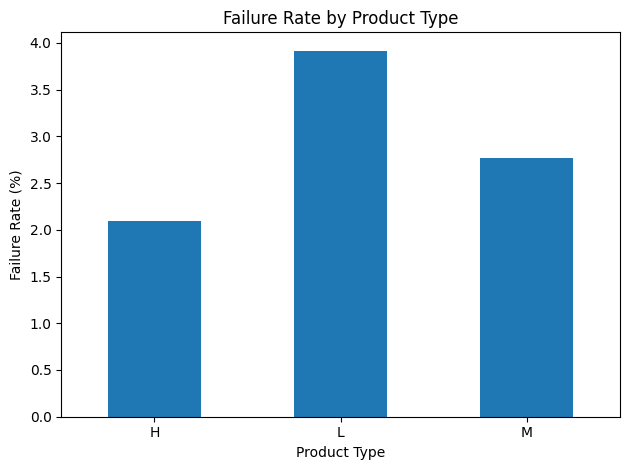

In [29]:
type_failure_rate.plot(kind="bar")

plt.title("Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "failure_rate_by_type.png")
plt.show()

## 제품 유형별 고장률 분석 결과

제품 유형별 고장률을 계산한 결과, `L` 타입의 고장률이 약 3.92%로 가장 높게 나타났다.

`M` 타입의 고장률은 약 2.77%, `H` 타입의 고장률은 약 2.09%로 확인되었다.

즉, 제품 유형에 따라 고장률에 차이가 존재하며, 이 데이터에서는 `L` 타입 제품이 상대적으로 고장 발생 비율이 높은 것으로 나타났다.

# 7. 센서 변수 분포 분석

제조 데이터에서 센서 변수는 장비 상태와 고장 여부를 파악하는 데 중요한 feature이다.

이번 단계에서는 주요 센서 변수의 분포를 히스토그램으로 시각화하여 각 센서값이 어떤 범위에 집중되어 있는지 확인한다.

분석 대상 센서 변수는 다음과 같다.

- `air_temp`: 공기 온도(K)
- `process_temp`: 공정 온도(K)
- `rot_speed`: 회전 속도(rpm)
- `torque`: 토크(Nm)
- `tool_wear`: 공구 마모 시간(min)

In [30]:
df[sensor_cols].describe()

,air_temp,process_temp,rot_speed,torque,tool_wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


## 센서 변수 기초 통계량 확인 결과

주요 센서 변수의 기초 통계량을 확인한 결과, 

`air_temp`의 평균은 약 300.00K, `process_temp`의 평균은 약 310.01K로 나타났다. 두 온도 변수는 표준편차가 각각 약 2.00, 1.48로 비교적 평균 주변에 안정적으로 분포하는 것으로 보인다.

`rot_speed`는 평균이 약 1538.78rpm이며, 최솟값은 1168rpm, 최댓값은 2886rpm으로 확인되었다. 특히 75% 값이 1612rpm인 것에 비해 최댓값이 2886rpm으로 높게 나타나 일부 큰 회전 속도 값이 존재할 가능성이 있다.

`torque`는 평균이 약 39.99Nm이며, 최솟값은 3.8Nm, 최댓값은 76.6Nm으로 확인되었다. 대부분의 값은 30~50Nm 근처에 분포하지만, 낮거나 높은 극단값이 존재할 수 있다.

`tool_wear`는 평균이 약 107.95분, 중앙값이 108분으로 나타났으며, 최솟값은 0분, 최댓값은 253분이다. 평균과 중앙값이 거의 유사하므로 전체적으로 비교적 균형 있게 분포하는 것으로 볼 수 있다.

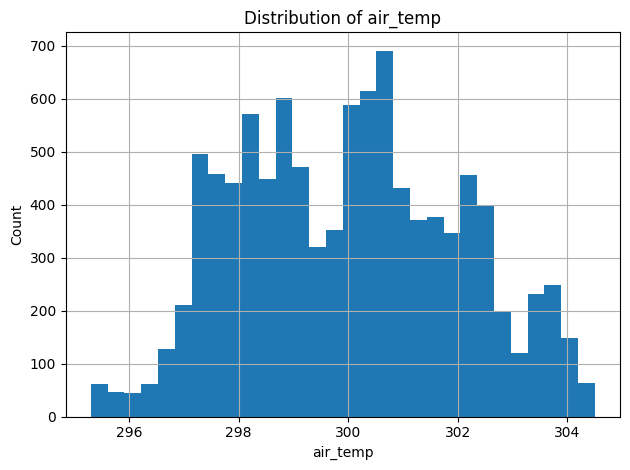

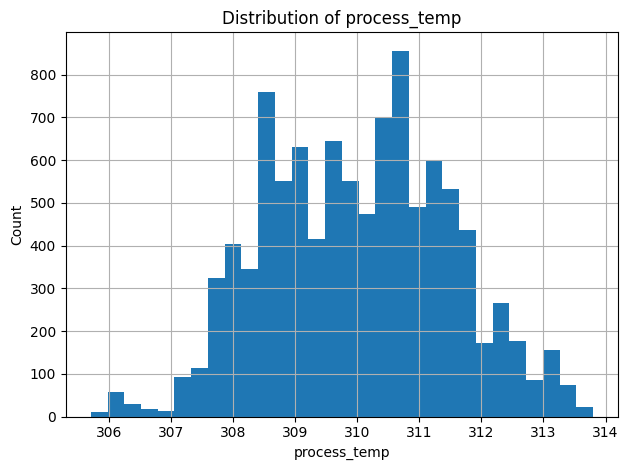

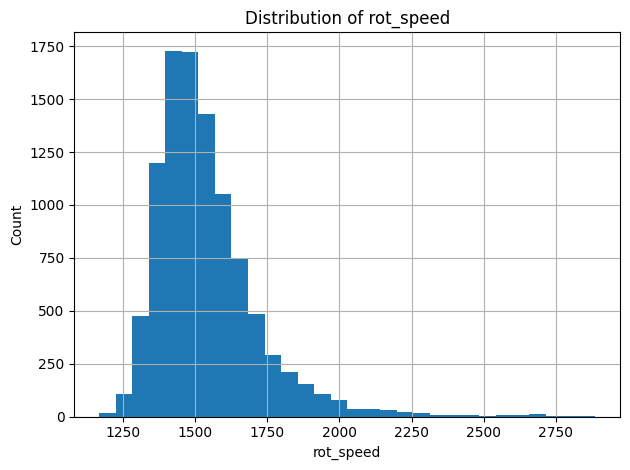

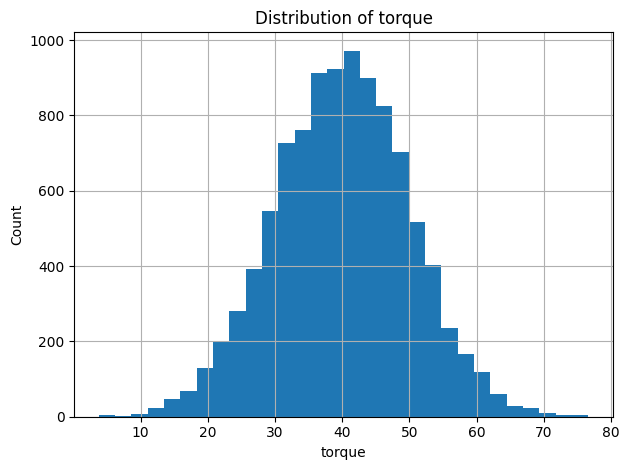

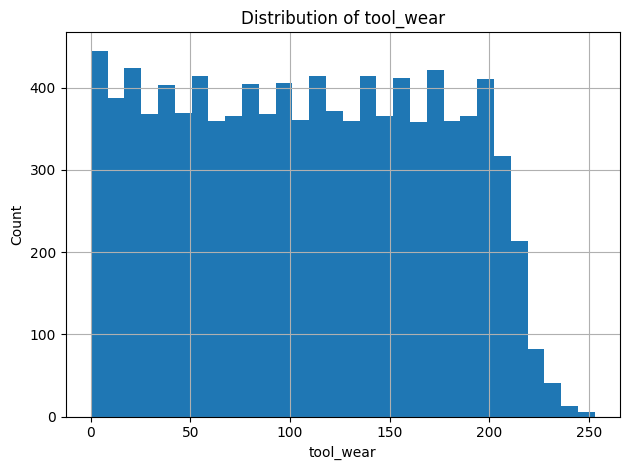

In [31]:
for col in sensor_cols:
    plt.figure()
    df[col].hist(bins=30)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    
    plt.savefig(FIGURE_DIR / f"distribution_{col}.png")
    plt.show()

## 히스토그램을 통한 주요 센서 변수의 분포를 확인 결과

온도 변수인 `air_temp`, `process_temp`는 평균 주변에 비교적 집중된 분포를 보였다.

`rot_speed`와 `torque`는 일부 구간에서 값이 넓게 퍼져 있으며, 이후 이상치 분석에서 추가 확인이 필요하다.

`tool_wear`는 0분부터 253분까지 분포하며, 공구 사용 시간에 따른 고장 여부와의 관계를 이후 단계에서 분석할 수 있다.